# Очистка датасета `flats_dataset`

Таблицу `flats_dataset` собрал DAG `prepare_flats_dataset`, данные в неё попали как есть, без обработки. Здесь смотрю, что с ними не так, пишу функции очистки и проверяю, что после них всё в порядке.

Эти же функции лежат в модуле `plugins/steps/clean_flats.py`, его использует DAG `clean_flats_dataset` (файл `dags/clean_flats_dataset.py`). В конце ноутбука сверяю результат модуля со здешним, чтобы код не разошёлся.

In [1]:
import os
import sys
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

%matplotlib inline

/var/folders/4l/70xpw14x7kd1jvxmsc32pw1m0000gn/T/ipykernel_34479/1891767396.py:6: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


## Читаем данные из личной базы

`flats_dataset` лежит в той же личной базе, доступы те же.

In [2]:
load_dotenv()

host = os.environ['DB_DESTINATION_HOST']
port = os.environ['DB_DESTINATION_PORT']
user = os.environ['DB_DESTINATION_USER']
password = os.environ['DB_DESTINATION_PASSWORD']
db_name = os.environ['DB_DESTINATION_NAME']

engine = create_engine(f'postgresql://{user}:{quote_plus(password)}@{host}:{port}/{db_name}')

In [3]:
data = pd.read_sql('select * from flats_dataset', engine)
data.head()

,id,flat_id,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator
0,1,0,6220,9,9.9,19.900000,1,False,False,35.099998,9500000.0,1965,6,55.717113,37.781120,2.64,84,12,True
1,2,1,18012,7,0.0,16.600000,1,False,False,43.000000,13500000.0,2001,2,55.794849,37.608013,3.00,97,10,True
2,3,2,17821,9,9.0,32.000000,2,False,False,56.000000,13500000.0,2000,4,55.740040,37.761742,2.70,80,10,True
3,4,3,18579,1,10.1,43.099998,3,False,False,76.000000,20000000.0,2002,4,55.672016,37.570877,2.64,771,17,True
4,5,4,9293,3,3.0,14.000000,1,False,False,24.000000,5200000.0,1971,1,55.808807,37.707306,2.60,208,9,True


In [4]:
print('Размер датасета:', data.shape)
data.dtypes

Размер датасета: (141362, 19)


id                     int64
flat_id                int64
building_id            int64
floor                  int64
kitchen_area         float64
living_area          float64
rooms                  int64
is_apartment            bool
studio                  bool
total_area           float64
price                float64
build_year             int64
building_type_int      int64
latitude             float64
longitude            float64
ceiling_height       float64
flats_count            int64
floors_total           int64
has_elevator            bool
dtype: object

In [5]:
data.describe()

,id,flat_id,building_id,floor,kitchen_area,living_area,rooms,total_area,price,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total
count,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,1.413620e+05,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000,141362.000000
mean,70681.500000,70680.500000,14053.665235,7.467346,9.001579,31.056948,2.129476,62.374644,1.944162e+07,1986.600048,3.232941,55.730059,37.589235,2.753650,251.993230,14.107554
std,40807.838714,40807.838714,6988.831066,5.717144,5.264076,23.968640,0.994340,40.295864,6.626954e+07,22.136409,1.459461,0.102611,0.150122,0.223275,207.336169,6.898045
min,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,11.000000,1.100000e+01,1901.000000,0.000000,55.211460,36.864372,2.000000,1.000000,1.000000
25%,35341.250000,35340.250000,8535.250000,3.000000,6.100000,19.000000,1.000000,39.299999,8.900000e+06,1969.000000,2.000000,55.653858,37.491764,2.640000,111.000000,9.000000
50%,70681.500000,70680.500000,14332.000000,6.000000,8.800000,29.400000,2.000000,53.000000,1.185000e+07,1985.000000,4.000000,55.724686,37.581146,2.640000,200.000000,14.000000
75%,106021.750000,106020.750000,20475.000000,10.000000,10.200000,41.400002,3.000000,72.000000,1.695000e+07,2007.000000,4.000000,55.807323,37.691055,2.800000,324.000000,17.000000
max,141362.000000,141361.000000,24620.000000,56.000000,203.000000,700.000000,20.000000,960.299988,9.873738e+09,2023.000000,6.000000,56.011032,37.946411,27.000000,4455.000000,99.000000


## 1. Дубликаты

`id` и `flat_id` уникальны по построению, поэтому искать дубликаты по ним бесполезно: строки не совпадут никогда. Сравниваю по всем остальным колонкам. Если две квартиры совпали по всем признакам - это одно объявление, загруженное дважды.

In [6]:
feature_cols = [col for col in data.columns if col not in ['id', 'flat_id']]

is_duplicated = data.duplicated(subset=feature_cols, keep='first')
print('Дубликатов (не считая первое вхождение):', int(is_duplicated.sum()))
print('Это {:.2%} строк'.format(is_duplicated.mean()))

Дубликатов (не считая первое вхождение): 9116
Это 6.45% строк


In [7]:
# keep=False показывает все вхождения, а не только повторы: так видно, что строки правда одинаковые
data[data.duplicated(subset=feature_cols, keep=False)].sort_values(feature_cols).head(10)

,id,flat_id,building_id,floor,kitchen_area,living_area,rooms,is_apartment,studio,total_area,price,build_year,building_type_int,latitude,longitude,ceiling_height,flats_count,floors_total,has_elevator
52640,52641,52640,3,3,0.0,0.000000,4,False,False,120.0,60000000.0,1901,1,55.759594,37.646488,3.2,26,4,False
54009,54010,54009,3,3,0.0,0.000000,4,False,False,120.0,60000000.0,1901,1,55.759594,37.646488,3.2,26,4,False
90882,90883,90882,4,4,11.0,48.000000,2,False,False,63.0,28000000.0,1902,1,55.748661,37.656487,3.0,32,4,False
122183,122184,122183,4,4,11.0,48.000000,2,False,False,63.0,28000000.0,1902,1,55.748661,37.656487,3.0,32,4,False
63568,63569,63568,6,5,10.0,74.000000,3,False,False,100.0,50000000.0,1902,1,55.754581,37.594685,3.2,15,6,True
63594,63595,63594,6,5,10.0,74.000000,3,False,False,100.0,50000000.0,1902,1,55.754581,37.594685,3.2,15,6,True
14477,14478,14477,10,3,0.0,0.000000,3,False,False,85.0,55500000.0,1902,1,55.764141,37.602577,3.1,20,22,False
107057,107058,107057,10,3,0.0,0.000000,3,False,False,85.0,55500000.0,1902,1,55.764141,37.602577,3.1,20,22,False
115310,115311,115310,10,3,0.0,0.000000,3,False,False,85.0,55500000.0,1902,1,55.764141,37.602577,3.1,20,22,False
138158,138159,138158,13,8,15.2,90.199997,4,False,False,130.0,49900000.0,1902,1,55.767918,37.598557,3.0,40,9,True


## 2. Пропуски

In [8]:
nulls = pd.DataFrame({'пропусков': data.isnull().sum(), 'доля': data.isnull().mean().round(4)})
nulls[nulls['пропусков'] > 0].sort_values('пропусков', ascending=False)

,пропусков,доля


In [9]:
print('Всего пропусков:', int(data.isnull().sum().sum()))
print('Строк хотя бы с одним пропуском:', int(data.isnull().any(axis=1).sum()))

Всего пропусков: 0
Строк хотя бы с одним пропуском: 0


Пусто, повезло. Значит, заполнять нечего, но функцию всё равно напишу - данные же обновятся.

## 3. Выбросы

Выбросы ищу только по непрерывным признакам: площади, высота потолков, цена, год постройки. Идентификаторы, координаты и категориальные признаки (`building_type_int`, булевы флаги) так проверять нельзя: у них большое значение не означает "странное".

In [10]:
continuous_cols = ['total_area', 'living_area', 'kitchen_area', 'ceiling_height', 'price', 'build_year']
data[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_area,141362.0,6.237464e+01,4.029586e+01,11.0,3.930000e+01,53.00,7.200000e+01,9.603000e+02
living_area,141362.0,3.105695e+01,2.396864e+01,0.0,1.900000e+01,29.40,4.140000e+01,7.000000e+02
kitchen_area,141362.0,9.001579e+00,5.264076e+00,0.0,6.100000e+00,8.80,1.020000e+01,2.030000e+02
ceiling_height,141362.0,2.753650e+00,2.232754e-01,2.0,2.640000e+00,2.64,2.800000e+00,2.700000e+01
price,141362.0,1.944162e+07,6.626954e+07,11.0,8.900000e+06,11850000.00,1.695000e+07,9.873738e+09
build_year,141362.0,1.986600e+03,2.213641e+01,1901.0,1.969000e+03,1985.00,2.007000e+03,2.023000e+03


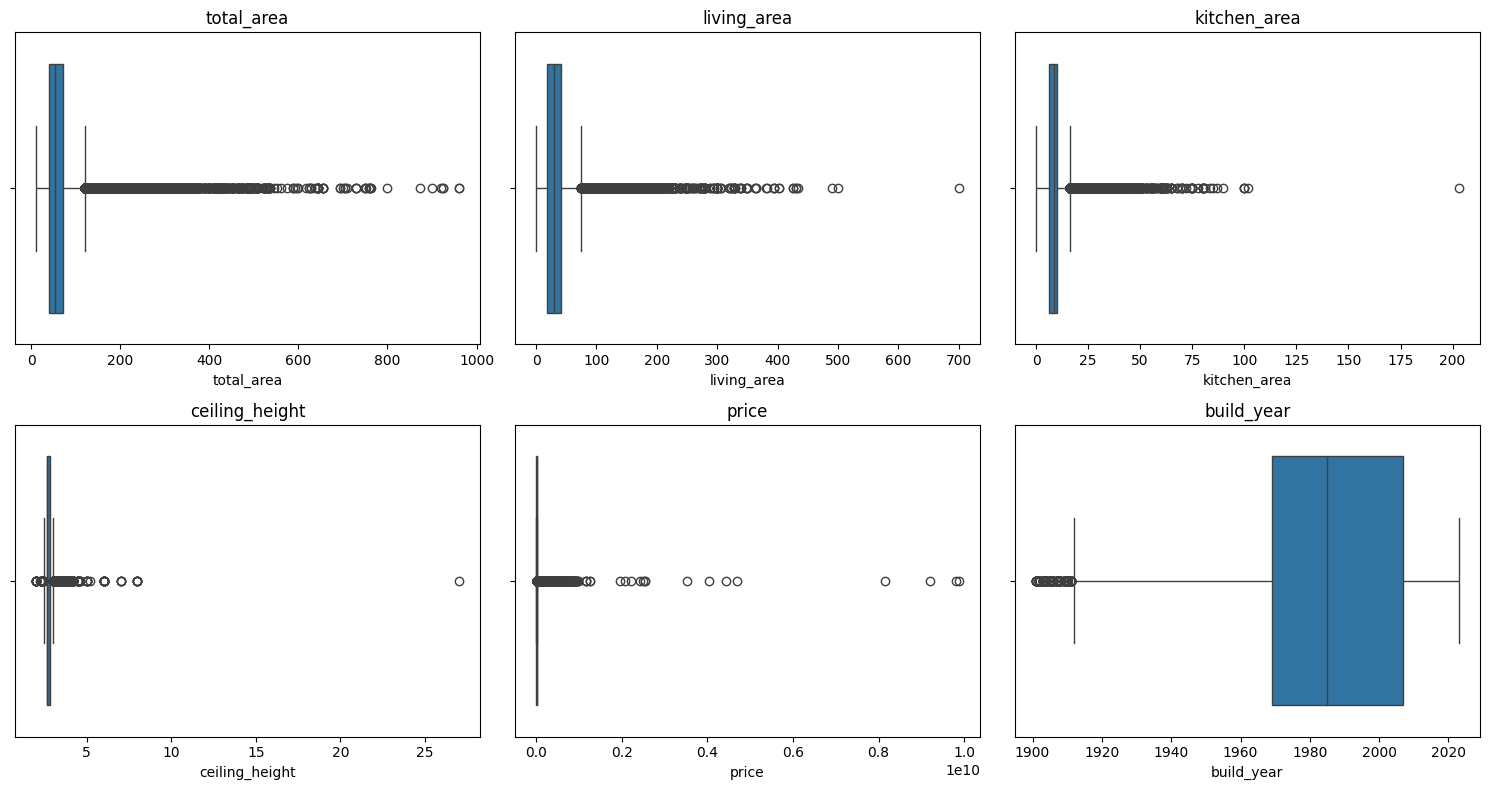

In [11]:
# на boxplot выбросы видно сразу: точки далеко за "усами"
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.boxplot(x=data[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Границы по методу IQR

Нормальными считаю значения в интервале `[Q1 - 1.5 * IQR, Q3 + 1.5 * IQR]`, где `IQR = Q3 - Q1`. Метод простой и не требует, чтобы признак был распределён нормально.

In [12]:
threshold = 1.5

bounds = []
for col in continuous_cols:
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - threshold * iqr
    upper = q3 + threshold * iqr
    outliers = int((~data[col].between(lower, upper) & data[col].notnull()).sum())
    bounds.append({'колонка': col, 'Q1': q1, 'Q3': q3, 'нижняя': lower, 'верхняя': upper, 'выбросов': outliers})

pd.DataFrame(bounds).set_index('колонка')

,Q1,Q3,нижняя,верхняя,выбросов
колонка,,,,,
total_area,3.930000e+01,7.200000e+01,-9.750002e+00,1.210500e+02,7839
living_area,1.900000e+01,4.140000e+01,-1.460000e+01,7.500000e+01,4962
kitchen_area,6.100000e+00,1.020000e+01,-4.999995e-02,1.635000e+01,8076
ceiling_height,2.640000e+00,2.800000e+00,2.400000e+00,3.040000e+00,9989
price,8.900000e+06,1.695000e+07,-3.175000e+06,2.902500e+07,14318
build_year,1.969000e+03,2.007000e+03,1.912000e+03,2.064000e+03,501


### Невозможные значения

Кроме статистических выбросов бывают значения, невозможные по смыслу. Их проверяю отдельно: IQR ловит не всё, нулевая цена по статистике может выбросом и не оказаться.

In [13]:
checks = {
    'цена меньше либо равна 0': data['price'] <= 0,
    'общая площадь меньше либо равна 0': data['total_area'] <= 0,
    'жилая площадь больше общей': data['living_area'] > data['total_area'],
    'этаж выше этажности дома': data['floor'] > data['floors_total'],
}

pd.Series({name: int(mask.sum()) for name, mask in checks.items()}, name='строк')

цена меньше либо равна 0             0
общая площадь меньше либо равна 0    0
жилая площадь больше общей           0
этаж выше этажности дома             0
Name: строк, dtype: int64

## Функции очистки

Три функции, дальше они же уходят в `plugins/steps/clean_flats.py`.

Пропусков в этой выгрузке не оказалось вообще, так что `fill_missing_values` отработала вхолостую. В DAG она всё равно нужна: данные обновляются, и пропуски появятся. Ставлю её первой, потому что строки, отличавшиеся только пропуском, после заполнения станут одинаковыми, и их подберёт шаг с дубликатами. Выбросы убираю последними - `between` считает пропуск выбросом, так что к этому моменту пропусков быть уже не должно.

Заполняю медианой, а не средним: среднее у цены задрано дорогими квартирами.

In [14]:
def fill_missing_values(data):
    data = data.copy()

    for col in data.columns:
        # id-шники медианой заполнять бессмысленно
        if col in ['id', 'flat_id'] or not data[col].isnull().any():
            continue

        if pd.api.types.is_numeric_dtype(data[col]) and not pd.api.types.is_bool_dtype(data[col]):
            data[col] = data[col].fillna(data[col].median())
        else:
            # для bool медианы нет, поэтому мода
            data[col] = data[col].fillna(data[col].mode()[0])

    return data


def remove_duplicates(data):
    # одно и то же объявление может лежать с разными id, поэтому id в сравнение не берём
    feature_cols = [col for col in data.columns if col not in ['id', 'flat_id']]
    is_duplicated = data.duplicated(subset=feature_cols, keep='first')
    return data[~is_duplicated].reset_index(drop=True)


def remove_outliers(data, threshold=1.5):
    """IQR-фильтр, threshold - сколько размахов допускаем."""
    # нулевая цена или площадь - это мусор в данных, IQR его не ловит
    data = data[(data['price'] > 0) & (data['total_area'] > 0)]

    for col in ['total_area', 'living_area', 'kitchen_area', 'ceiling_height', 'price', 'build_year']:
        q1 = data[col].quantile(0.25)
        q3 = data[col].quantile(0.75)
        iqr = q3 - q1
        data = data[data[col].between(q1 - threshold * iqr, q3 + threshold * iqr)]

    return data.reset_index(drop=True)

## Применяем функции

In [15]:
print('Было строк:', len(data))

cleaned = fill_missing_values(data)
print('После заполнения пропусков:', len(cleaned), '| пропусков осталось:', int(cleaned.isnull().sum().sum()))

cleaned = remove_duplicates(cleaned)
print('После удаления дубликатов:', len(cleaned))

cleaned = remove_outliers(cleaned)
print('После удаления выбросов:', len(cleaned))

print('Всего удалено: {} строк ({:.2%})'.format(len(data) - len(cleaned), 1 - len(cleaned) / len(data)))

Было строк: 141362
После заполнения пропусков: 141362 | пропусков осталось: 0
После удаления дубликатов: 132246
После удаления выбросов: 82877
Всего удалено: 58485 строк (41.37%)


In [16]:
assert cleaned.isnull().sum().sum() == 0, 'остались пропуски'
assert cleaned.duplicated(subset=feature_cols).sum() == 0, 'остались дубликаты'
assert (cleaned['price'] > 0).all(), 'осталась цена меньше либо равная нулю'
assert (cleaned['total_area'] > 0).all(), 'осталась площадь меньше либо равная нулю'
print('Проверки прошли, данные чистые')

Проверки прошли, данные чистые


In [17]:
# та же describe, только после очистки
cleaned[continuous_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
total_area,82877.0,5.017901e+01,1.488698e+01,11.5,3.810000e+01,4.600000e+01,5.900000e+01,120.00
living_area,82877.0,2.763463e+01,1.277581e+01,0.0,1.900000e+01,2.820000e+01,3.440000e+01,69.00
kitchen_area,82877.0,8.516164e+00,2.161487e+00,1.5,6.500000e+00,8.500000e+00,1.000000e+01,15.84
ceiling_height,82877.0,2.663347e+00,6.090620e-02,2.5,2.640000e+00,2.640000e+00,2.700000e+00,2.88
price,82877.0,1.102065e+07,3.481494e+06,1000000.0,8.400000e+06,1.050000e+07,1.310000e+07,21000000.00
build_year,82877.0,1.985935e+03,1.761842e+01,1926.0,1.970000e+03,1.982000e+03,2.002000e+03,2023.00


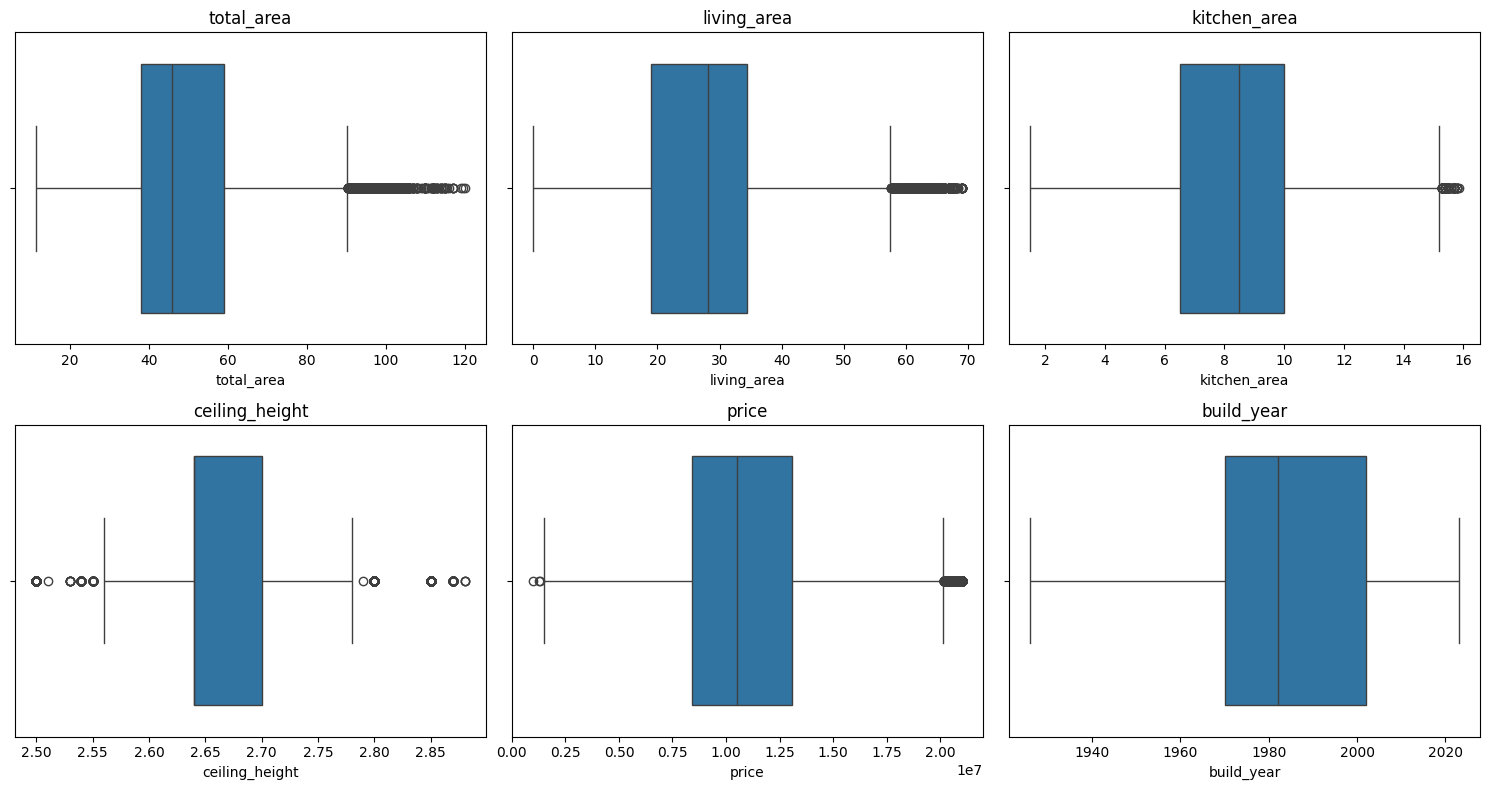

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), continuous_cols):
    sns.boxplot(x=cleaned[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## Сверяем с модулем `plugins/steps/clean_flats.py`

DAG берёт функции не из ноутбука, а из модуля в папке `plugins` (Airflow сам добавляет её в `sys.path`).
Чтобы не получилось так, что в ноутбуке один код, а в DAG другой, прогоняю данные через модуль
и сравниваю результат с тем, что получилось выше.

In [19]:
sys.path.append('../plugins')

from steps import clean_flats

by_module = clean_flats.fill_missing_values(data)
by_module = clean_flats.remove_duplicates(by_module)
by_module = clean_flats.remove_outliers(by_module)

assert by_module.shape == cleaned.shape, 'у модуля другой размер результата'
assert by_module.equals(cleaned), 'у модуля другие данные'
print('Модуль даёт тот же результат:', by_module.shape)

Модуль даёт тот же результат: (82877, 19)


## Выводы

Дубликатов нашлось 9 116, это 6.45% строк, пропусков ноль. Почти всё остальное съел IQR: из 141 362 строк осталось 82 877, то есть минус 41%. Порог 1.5 сразу по шести признакам режет очень сильно, особенно по цене. Пока оставляю как есть, но если модель будет плохо предсказывать дорогие квартиры - вернусь сюда и ослаблю порог.

Порядок шагов менять нельзя: пропуски -> дубликаты -> выбросы.

Три функции лежат в `plugins/steps/clean_flats.py` и вызываются в шаге `transform` DAG `clean_flats_dataset`, который читает `flats_dataset` и сохраняет результат в таблицу `clean_flats_dataset`.

In [20]:
engine.dispose()